In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance

In [2]:
# File Paths 
PATH_TRAIN_DATA = "/Users/anirudhsudhir/Ecole Python/train.csv" 
PATH_TEST_FEATURES = "/Users/anirudhsudhir/Ecole Python/test-full.csv" 
PATH_TEST_TARGET = "/Users/anirudhsudhir/Ecole Python/full_submission.csv"

In [3]:
# Load Data
def get_train_data(path=PATH_TRAIN_DATA):
    df = pd.read_csv(path, index_col="Id")
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]
    return X, y

def get_test_data(path=PATH_TEST_FEATURES):
    df = pd.read_csv(path, index_col="Id")
    return df

X_train, y_train = get_train_data()
X_test = get_test_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print("Target distribution:\n", y_train.value_counts())

Training data shape: (15120, 54)
Test data shape: (581012, 54)
Target distribution:
 Cover_Type
1    2160
2    2160
3    2160
4    2160
5    2160
6    2160
7    2160
Name: count, dtype: int64


In [5]:
# Multi-Model Feature Selection (prefit)
RANDOM_STATE = 42

models_fs = {
    "lgbm": LGBMClassifier(n_estimators=500, random_state=RANDOM_STATE),
    "rf": RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1),
    "logreg": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(penalty='l1', solver='saga', C=0.5, max_iter=5000, random_state=RANDOM_STATE))
    ])
}

feature_sets = []

for name, model in models_fs.items():
    print(f"Fitting model for feature selection: {name}")
    model.fit(X_train, y_train)
    
    # Extract importances
    if name in ["lgbm", "rf"]:
        imp = pd.Series(model.feature_importances_, index=X_train.columns)
    else:  # Logistic Regression L1
        imp = pd.Series(np.abs(model.named_steps["model"].coef_[0]), index=X_train.columns)
    
    # Keep features above median
    top_features = imp[imp > imp.median()].index.tolist()
    feature_sets.append(set(top_features))

# Intersection of top features across models for robustness
robust_features_multi = set.intersection(*feature_sets)
X_train_selected = X_train[list(robust_features_multi)].copy()
X_test_selected = X_test[list(robust_features_multi)].copy()
print("Features after multi-model agreement:", X_train_selected.shape[1])

Fitting model for feature selection: lgbm
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001044 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2166
[LightGBM] [Info] Number of data points in the train set: 15120, number of used features: 44
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
Fitting model for feature selection: rf
Fitting model for feature selection: logreg
Features after multi-model agreement: 15


In [6]:
# Cross-Validated Feature Importance (LGBM)

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

feature_importances_cv = pd.DataFrame(0, index=X_train_selected.columns, columns=range(N_FOLDS))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_selected, y_train)):
    X_tr, X_val = X_train_selected.iloc[train_idx], X_train_selected.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = LGBMClassifier(n_estimators=500, random_state=RANDOM_STATE)
    model.fit(X_tr, y_tr)
    
    feature_importances_cv[fold] = model.feature_importances_

# Keep features appearing in most folds
fold_threshold = 0.6 * N_FOLDS
stable_features = feature_importances_cv.apply(lambda x: x > 0).sum(axis=1)
robust_features_cv = stable_features[stable_features >= fold_threshold].index.tolist()
X_train_robust = X_train_selected[robust_features_cv].copy()
X_test_robust = X_test_selected[robust_features_cv].copy()
print("Features after CV stability check:", X_train_robust.shape[1])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000749 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1542
[LightGBM] [Info] Number of data points in the train set: 12096, number of used features: 15
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000844 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1547
[LightGBM] [Info] Number of data points in the train set: 12096, number of used features: 15
[LightGBM] [Info] Start training from score 

In [7]:
# Permutation Importance
final_model = LGBMClassifier(n_estimators=500, random_state=RANDOM_STATE)
final_model.fit(X_train_robust, y_train)

perm_importance = permutation_importance(
    final_model, X_train_robust, y_train, n_repeats=20, random_state=RANDOM_STATE
)
perm_importances = pd.Series(perm_importance.importances_mean, index=X_train_robust.columns)

# Keep only features with positive permutation importance
robust_features_final = perm_importances[perm_importances > 0].index.tolist()
X_train_final = X_train_robust[robust_features_final].copy()
X_test_final = X_test_robust[robust_features_final].copy()

print("Final feature count:", X_train_final.shape[1])
print("Final selected features:\n", robust_features_final)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002503 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1554
[LightGBM] [Info] Number of data points in the train set: 15120, number of used features: 15
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
Final feature count: 15
Final selected features:
 ['Wilderness_Area4', 'Soil_Type23', 'Vertical_Distance_To_Hydrology', 'Hillshade_9am', 'Soil_Type13', 'Soil_Type2', 'Soil_Type17', 'Soil_Type4', 'Hillshade_Noon', 'Elevation', 'Horizontal_Distance_To_Roadways', 'Soil_Type10', 'Wilderness_Area1', 'Hillshade_3pm', 'Aspect']


/var/folders/y9/hsmfhh2572z90v6trpwvxzh80000gn/T/ipykernel_85421/489245718.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


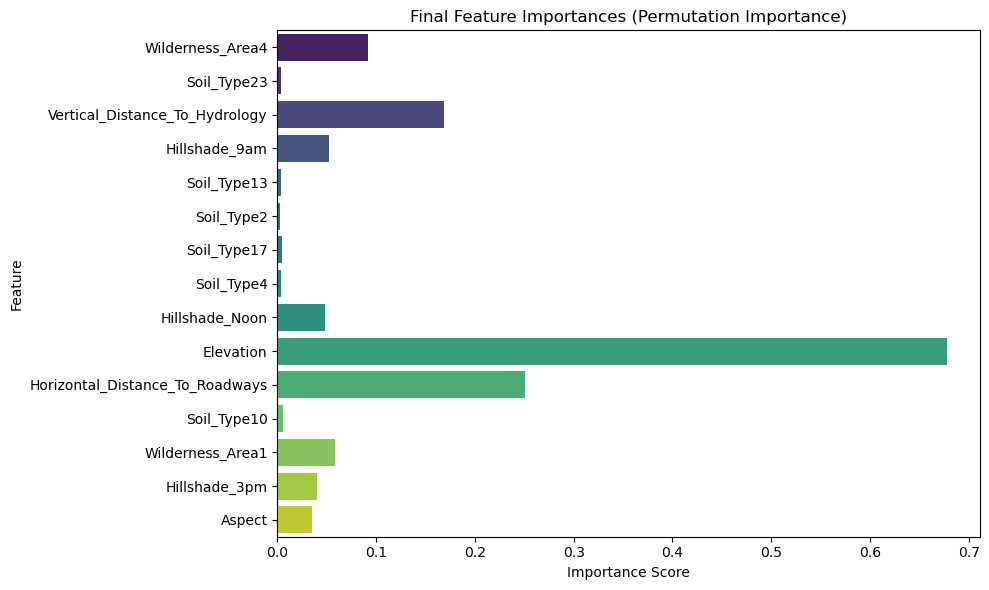

In [8]:
# Visualize Final Permutation Importances
plt.figure(figsize=(10,6))
sns.barplot(
    x=perm_importances[robust_features_final].values, 
    y=perm_importances[robust_features_final].index,
    palette="viridis"
)
plt.title("Final Feature Importances (Permutation Importance)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [9]:
# Export Final Feature Sets for Modeling
print("Final train shape:", X_train_final.shape)
print("Final test shape:", X_test_final.shape)

# Export to CSV
X_train_final.to_csv("X_train_final.csv", index=True)
X_test_final.to_csv("X_test_final.csv", index=True)

Final train shape: (15120, 15)
Final test shape: (581012, 15)
